# 15 · Gradient boosting with a feature-engineering plan (dev preview)

**Use case.** The relational graph models learn features from the neighbourhood; a gradient-boosted tree wants them written down as columns. Langsat's GBM lane does that with a **feature-engineering SQL plan**: SQL over the cleaned tables that produces one row per entity with engineered columns — generated by the model from your task, or written by you — and then trains LightGBM on it. This chapter reviews the cleaning plan, generates the feature plan, edits it by hand, previews, trains LightGBM and reads the result.

**Model / lane:** LightGBM on a feature-plan table (dev)

**What you will learn**
1. Where the GBM lane is today: dev only, behind flags — and what that means for this chapter
2. The model menu with a `gbm` family next to `neural`
3. The cleaning plan on a `data_science` project (the training pipeline runs it — review it first)
4. `POST /feature-plan/generate`: an LLM writes the feature SQL for your task; read the SQL, the columns, the roles
5. Edit the SQL yourself, `preview` it (columns and a sample), `PUT` it — your version wins
6. Train `model_key="lightgbm"`; the engine fields on the model row; feature importance
7. Serving: a GBM model predicts from a row's values; a plan that joins related tables cannot score one row alone

**What this costs.** one GBM training run and one feature-plan generation (1,000 credits — an Opus call) on the dev environment's test account.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

> **Preview.** This chapter runs against the **dev** environment with a signed-in session, not an API key on `api.langsat.ai`: the GBM lane (`gbm_lane`, `gbm_picker`, `gbm_feature_plan_llm`) is on in dev and blocked in prod until its serving path ships, and feature-plan generation / hand-written feature SQL are **human-only** calls (the SQL runs on the machine that trains your data — an API key is refused there, as in chapter 14). To run it yourself: `LANGSAT_BASE_URL=<dev api>` and a session token in `LANGSAT_API_KEY`. Everything else in this repo runs on prod with a key.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as max-test@langsat.dev · tier max · key 'None' with 0 scopes


In [2]:
env = ls.base_url
print("environment:", env)
plan = ls.me()["tier"]
menu = ls.request("GET", f"/tiers/{plan}/models", params={"mode": "relational"})
pd.DataFrame(menu["models"])

environment: https://iw1bdxj2y7.execute-api.ap-southeast-1.amazonaws.com/prod/api/v1


,key,label,family
0,sage_baseline,Baseline,neural
1,sage_full,SAGE,neural
2,gatv2_full,GAT,neural
3,gin,GIN,neural
4,lightgbm,LightGBM,gbm


## 1 · The project and the task

The same three tables; a `data_science` project. The task is defined first — the feature plan is written *for* a task (its entity, its target, its time column).

In [3]:
p = get_or_create_project(ls, "gbm", kind="data_science")
before = credits_used(ls)
cfg = p.refresh().data.get("task_config")
if not cfg:
    job = p.tasks.define("Predict the rating a review gives, from the review text, its summary, the product and the customer",
                         task_type="supervised", subtask_type="regression").wait(timeout=600)
    cfg = p.refresh().data.get("task_config")
cfg = json.loads(cfg) if isinstance(cfg, str) else cfg
print({k: cfg.get(k) for k in ("task_type", "entity_table", "target_col", "text_embed_columns")})

reusing project 1d4c9ae5-3087-4ef4-9015-8ed189a2b4c4 (amazon-reviews-gbm, status=ready)


files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
project ready: status=ready · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


{'task_type': 'regression', 'entity_table': 'review', 'target_col': 'rating', 'text_embed_columns': {'review': ['review_text', 'summary'], 'product': ['description', 'title']}}


## 2 · The cleaning plan, on a training project

A `data_science` project has no separate clean step — the training pipeline runs the cleaning plan — but the plan is there to review and change exactly as in chapter 14. The brand fix from that chapter is saved here too, so the feature SQL below sees real author names.

In [4]:
pl = p.cleaning.plan()
print("status:", pl["status"], "· transforms:", sum(1 for t in pl["plan"]["tables"].values() for c in t["columns"].values() if c["action"] == "transform"))
saved = p.cleaning.save({"product": {"columns": {
    "brand": {"action": "transform", "ops": [{"op": "regexp_replace", "params": {"pattern": "^Visit Amazon's (.*) Page$", "replacement": "\\1"}, "reason": "the author's name"}, {"op": "trim", "params": {}}]},
    "category": {"action": "transform", "ops": [{"op": "null_if_in", "params": {"values": ["\\N", ""]}}, {"op": "replace", "params": {"find": "&amp;", "replace": "&"}}]}}}})
print("\n".join(l for l in saved["compiled_sql"].splitlines() if "@col:brand" in l))

status: pending_review · transforms: 4


    /*@col:brand*/ TRIM(REGEXP_REPLACE("brand", '^Visit Amazon''s (.*) Page$', '\1', 'g')) AS "brand",


## 3 · Generate the feature plan

`POST /feature-plan/generate` asks the model for feature SQL: one row per entity of the task (here a review) with engineered columns — text lengths and lexicon hits, product and customer attributes, counts over their other reviews — each with a **role** (`static`, `past_derived`, `known_future`, `key`). It costs 1,000 credits, runs as a job, and lands as `status: ready`. The SQL is yours to read.

The validator runs every plan against a sample and refuses what would fool the model: a window that includes the row being predicted, a column that *is* the label, a feature built out of the row id, a column the cleaning step drops — and, on a task like this one with no time order, **any use of the target column in a feature**. The tempting "mean rating of the product's *other* reviews" is `(sum − own rating) / (n − 1)`: inside a product that is a straight line in the row's own rating, and a tree model reads the label straight off it. This chapter's first draft had exactly that column, scored R² 0.95, and put 62 % of its importance on it — which is what a leak looks like.

In [5]:
fp = ls.request("GET", f"/projects/{p.id}/feature-plan")
print("feature plan:", fp["status"], "· generation enabled:", fp["generation_enabled"], "· cost:", fp.get("generation_cost_credits"))
if fp["status"] in ("none", "failed"):
    fp = ls.request("POST", f"/projects/{p.id}/feature-plan/generate", json={"goal": "features that explain a review's rating: the product's other ratings, the customer's history, text length and recency"})
    import time
    while fp["status"] == "generating":
        time.sleep(5)
        fp = ls.request("GET", f"/projects/{p.id}/feature-plan/status/{fp['job_id']}")
print("status:", fp["status"], "· origin:", fp.get("origin"), "· columns:", len(fp["columns"]), "· warnings:", fp["warnings"])
print(pd.Series(fp["roles"]).value_counts().to_dict() if isinstance(fp.get("roles"), dict) else fp.get("roles"))
print(fp["sql"])

feature plan: ready · generation enabled: True · cost: 1000
status: ready · origin: user · columns: 37 · warnings: ["'long_review' has no declared role — treating it as 'past_derived', which means it will be FROZEN at its last known value when predicting. If it is really a calendar or price column, declare it known_future or the model will be handed a stale value."]
{'static': 24, 'past_derived': 12, 'key': 1}
-- LANGSAT_FEATURE_FORMAT: v1-duckdb-sql
WITH generated AS (
WITH cust AS (
  SELECT customer_id,
         count(*) AS n_reviews,
         count(DISTINCT product_id) AS n_products,
         avg(CAST(verified AS DOUBLE)) AS ver_share,
         avg(length(coalesce(review_text,''))) AS avg_len,
         min(CAST(review_time AS TIMESTAMP)) AS first_t,
         max(CAST(review_time AS TIMESTAMP)) AS last_t
  FROM review
  GROUP BY 1
),
prod AS (
  SELECT product_id,
         count(*) AS n_reviews,
         count(DISTINCT customer_id) AS n_customers,
         avg(CAST(verified AS DOUBL

## 4 · Edit it, preview it, keep your version

The plan is SQL, so you can change it: here one more feature — the length of the review text — is added to the SELECT. `preview` compiles and runs it on a sample (columns, roles, warnings) without saving; `PUT` stores it with `origin: user`. A stale plan (the schema or cleaning changed after it was written) is refused at train time, before a box boots.

In [6]:
sql = fp["sql"]
header, body = (sql.split("\n", 1) + [""])[:2] if sql.startswith("--") else ("", sql)
length_col = next((c for c in fp["columns"] if any(k in c for k in ("text_chars", "n_chars", "text_len", "review_len", "text_words", "n_words"))), None)
if length_col and "long_review" not in fp["columns"]:
    # wrap the generated query as a CTE and add one column of our own on top of it
    edited = f"{header}\nWITH generated AS (\n{body}\n)\nSELECT g.*, CASE WHEN g.{length_col} > 500 THEN 1 ELSE 0 END AS long_review FROM generated g"
    pv = ls.request("POST", f"/projects/{p.id}/feature-plan/preview", json={"sql": edited})
    print("preview:", pv["status"], "· columns:", len(pv["columns"]), "· new:", sorted(set(pv["columns"]) - set(fp["columns"])), "· warnings:", len(pv["warnings"]))
    if pv["status"] == "ready" and "long_review" in pv["columns"]:
        fp = ls.request("PUT", f"/projects/{p.id}/feature-plan", json={"sql": edited})
        print("saved:", fp["status"], "· origin:", fp["origin"], "· columns:", len(fp["columns"]), "· role of long_review:", fp["roles"].get("long_review"))
    else:
        print("kept the generated plan:", pv.get("error") or pv["warnings"][:1])
else:
    print("plan already carries our column (or no length feature to build on):", fp.get("origin"), len(fp["columns"]))

preview: ready · columns: 39 · new: ['long_review', 'long_review_1'] · warnings: 2


saved: ready · origin: user · columns: 39 · role of long_review: past_derived


## 5 · Train LightGBM

`model_key="lightgbm"` selects the GBM lane. The run reads the cleaned tables, materialises the feature plan (its columns are added to the lane's own per-entity aggregates), runs a hyper-parameter search with early stopping on the validation split and writes the same model row as the neural lane — plus `engine == "gbm"`, the library, and `n_features`, the width of the frame it trained on. No text embeddings here: the GBM lane sees the text only through what the plan computes from it (lengths, lexicon hits), which is the honest reason its number sits below the graph model's.

In [7]:
from _common import wait_for_training, known_models
model = next((m for m in project_models(p) if m.get("metrics") and (m.get("engine") == "gbm" or m.get("model_type") == "lightgbm")), None)
if model is None:
    minutes = int(p.estimates()["train"]["suggested_minutes"]) + 2
    known = known_models(p)
    p.train(model_key="lightgbm", max_training_min=minutes)
    model = wait_for_training(p, known_model_ids=known)
hp = {k: model.get(k) for k in ("engine", "lib", "lib_version", "n_features")}
print(model["version_label"], model["model_type"], "·", hp)
show(model["metrics"], keys=("mae", "rmse", "r2", "spearman"))
print("read these against chapters 12–13 (graph MAE 0.476 / R² 0.48, FT-Transformer 0.471 / 0.33): a number far beyond them is a leak, not a win")

v1 lightgbm · {'engine': 'gbm', 'lib': 'lightgbm', 'lib_version': '4.5.0', 'n_features': 46}
  r2                     0.2258
  mae                    0.6262
  rmse                   0.8754
  spearman               0.4132
read these against chapters 12–13 (graph MAE 0.476 / R² 0.48, FT-Transformer 0.471 / 0.33): a number far beyond them is a leak, not a win


always-mean baseline MAE 0.770 · LightGBM MAE 0.626


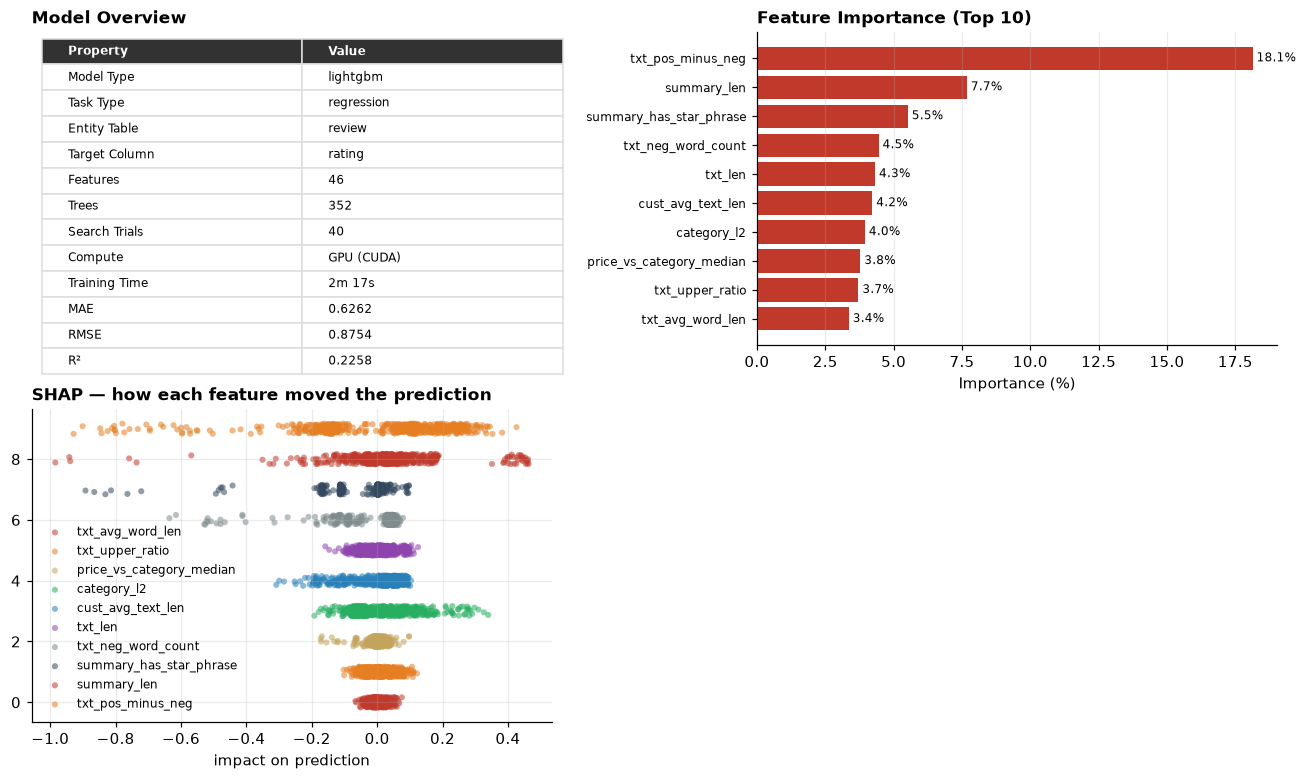

In [8]:
review = pd.read_csv(DATA_DIR / "review.csv") if "DATA_DIR" in dir() else None
from _common import DATA_DIR
review = pd.read_csv(DATA_DIR / "review.csv")
print(f"always-mean baseline MAE {(review['rating'] - review['rating'].mean()).abs().mean():.3f} · LightGBM MAE {model['metrics']['mae']:.3f}")
fig(viz.model_dashboard(p, cols=2))

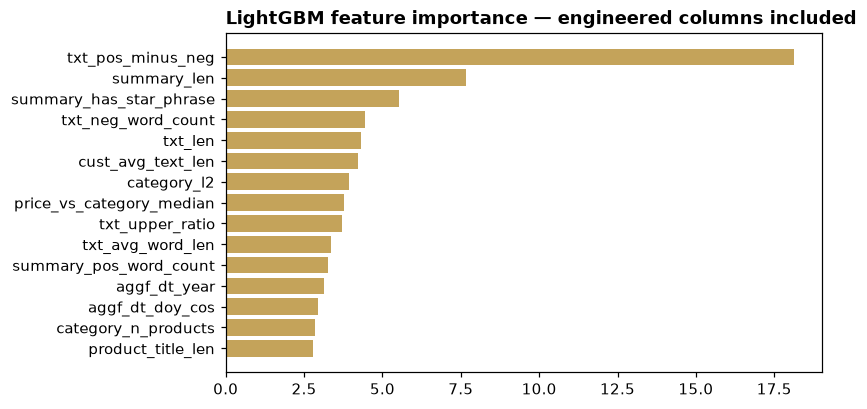

In [9]:
imp = ls.predict.importance(model["model_id"]) if hasattr(ls.predict, "importance") else p.models.importance(model["model_id"])
feats = imp.get("features") or imp
top = pd.DataFrame(feats[:15], columns=["feature", "importance"]) if isinstance(feats, list) else pd.Series(feats).sort_values(ascending=False).head(15).rename_axis("feature").reset_index(name="importance")
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(7, 4)); ax.barh(top["feature"][::-1], top["importance"][::-1], color="#c4a35a"); ax.set_title("LightGBM feature importance — engineered columns included", loc="left", fontweight="bold"); fig(f)

## 6 · What does not work yet — on purpose

A GBM model predicts from **feature values**, not from a stored id — there is no graph to look a row up in — so `/predict` wants `mode="inductive"` with the row. And a plan that joins the related tables (this one aggregates the customer's and the product's other reviews) cannot be applied to one row arriving alone: the serving side refuses with the feature query's own error rather than score on half a frame. Plans built from the entity's own columns only would serve; that, and the prod flags, are why this chapter is a preview.

`/predict` is the public API and takes an **API key**, not a session — so this cell mints a one-day `predict`-only key from the session (the same call Settings → API keys makes), uses it once, and deletes it.

In [10]:
from langsat import errors, Langsat
key = ls.request("POST", "/api-keys", json={"name": "gbm-chapter", "scopes": ["predict"], "expires_in_days": 1})
try:
    api = Langsat(token=key["key"], base_url=ls.base_url)               # a second client: the key, not the session
    schema = api.predict.model(model["model_id"])
    print("required features:", schema["required_features"])
    row = {"review_text": "Loved it, read it twice.", "summary": "Great", "verified": 1, "product_id": 246851, "customer_id": 1474411}
    api.predict.predict(model_id=model["model_id"], mode="inductive", features={k: row[k] for k in schema["required_features"]})
except errors.LangsatError as e:
    print(type(e).__name__, "·", e.status, e.code, "·", str(e.message)[:200])
finally:
    ls.request("DELETE", f"/api-keys/{key['id']}"); print("key deleted")

required features: ['customer_id', 'product_id', 'review_text', 'summary', 'verified']


Conflict · 409 conflict · The saved feature query could not be applied to this data, so this model cannot predict from it. [ERR_FEATURE_SQL_INVALID] The feature query could not run against this data.: CatalogException: Catalog


key deleted


In [11]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "15_gbm_feature_plan", "task": "regression · LightGBM on a feature-engineering SQL plan (dev preview)", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"], "training_duration_sec": model.get("training_duration_sec"), "credits_charged_this_run": charged,
                   "headline": {"mae": model["metrics"].get("mae"), "rmse": model["metrics"].get("rmse"), "r2": model["metrics"].get("r2"),
                                "n_features": hp.get("n_features"), "feature_plan_origin": fp.get("origin"), "environment": "dev"}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [14 · The cleaning plan](../14_cleaning_plan/) — the same plan on an analysis project
- [13 · Choose your model](../13_choose_your_model/) — the neural menus this lane sits beside
- When the GBM lane reaches prod, this chapter runs with an API key like the others